# 6.1 The Dehydration of Ethanol

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume VI — Reactions and Free Energy",
    number="6.1",
    title="The Dehydration of Ethanol",
    blurb="A reaction profile from first principles: ethanol splits into ethene and "
    "water over a transition state, and the activation barrier depends sharply on the "
    "density functional and basis set used to compute it.",
    difficulty="intermediate",
    estimate="75–100 min",
    source="FS 2023 · Lecture 7 (density functionals and basis sets)",
)

<ECP header: 2807 chars of HTML>

## Notebook overview

Heat ethanol over an acid catalyst and it loses water, leaving ethene:
$\mathrm{CH_3CH_2OH \to CH_2{=}CH_2 + H_2O}$. The reaction does not happen all at
once; it passes through a **transition state**, a fleeting arrangement at the top of
an energy barrier where the C–O bond is breaking and a C–H bond is migrating. The
height of that barrier sets the rate, and computing it is a standard test of an
electronic-structure method.

This is the course's exercise on **density functionals and basis sets**, and its
point is that the answer depends on the method. We take the course's own optimised
structures (reactant, transition state, products) and its committed total energies,
computed with two functionals (**PBE** and **B3LYP**) across three basis sets
(**SZV**, **DZVP**, **TZVP**), and build the reaction-energy profile, extract the
activation barrier and reaction energy, watch them converge with basis-set size, and
turn the barrier into a reaction rate.

> **Provenance.** This notebook develops **Lecture 7** of the course (the dehydration
> of ethanol, density functionals, and basis sets), an exercise **designed by the
> author (Raymond Amador)**. The molecular structures
> (`ethanol.xyz`, `ethene.xyz`, `H2O.xyz`, `ts.xyz`) and the total energies are the
> course's own committed CP2K results; energies were computed with PBE and B3LYP. The
> full course credit is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: a transition state must lie above the reactant, the reaction is known to be
> endothermic, a converged barrier should match the measured one. A ✗ flags a
> mismatch; a ✓ is strong evidence, not proof.

> **Scope.** Energies are the committed density-functional totals (in Hartree,
> converted to kcal/mol); we analyse them rather than recompute them, since a
> hybrid-functional calculation is far beyond a notebook. For the methods see the
> PBE {cite}`pbe1996` and B3LYP {cite}`becke1993` functionals.

## Theory in brief

### Reaction profile and the barrier

A reaction's energy along its path rises from the **reactant** to a maximum at the
**transition state**, then falls to the **products**. Two numbers summarise it: the
**activation barrier**

```{math}
:label: eq-barrier
\Delta E^{\ddagger} = E_{\rm TS} - E_{\rm reactant},
```

which controls the rate, and the **reaction energy**
$\Delta E = E_{\rm products} - E_{\rm reactant}$, which says whether the reaction
absorbs energy (endothermic, $\Delta E>0$) or releases it. Ethanol dehydration is
endothermic and has a high barrier, which is why it needs heat and a catalyst.

### Functionals and basis sets

A density-functional calculation makes two approximations we can see here. The
**exchange-correlation functional** (the generalised-gradient **PBE**, or the hybrid
**B3LYP** that mixes in exact exchange) sets the underlying physics; the **basis set**
(here the increasingly flexible **SZV** $\to$ **DZVP** $\to$ **TZVP**) sets how
accurately the orbitals are represented. A result is trustworthy only once it has
**converged** with basis-set size, and different functionals can still disagree after
convergence: barriers are a sensitive probe of both.

### From barrier to rate

Transition-state theory turns the barrier into a rate constant through the Eyring (or,
equivalently, Arrhenius) form

```{math}
:label: eq-eyring
k(T) \propto \exp\!\left(-\frac{\Delta E^{\ddagger}}{k_B T}\right),
```

exponentially sensitive to the barrier, so the few-kcal/mol spread between methods
becomes orders of magnitude in the predicted rate.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
HARTREE_KCAL = 627.503                # Hartree -> kcal/mol
KB_KCAL = 1.987204e-3                 # Boltzmann constant [kcal/mol/K]
CPK = {"H": "#d9d9d9", "C": "#303030", "O": "#c0392b", "N": "#2c5fb0"}
RADIUS = {"H": 0.31, "C": 0.76, "O": 0.66, "N": 0.71}   # covalent radii [Å]


def data_file(name):
    """Locate a shipped data file from the repo root (CI) or the notebook dir (Colab)."""
    for base in ("data", os.path.join("notebooks", "06-reactions-free-energy", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_xyz(name):
    """Read an .xyz file: returns (elements, coords) with coords in Å."""
    lines = open(data_file(name)).read().splitlines()
    n = int(lines[0].split()[0])
    els, xyz = [], []
    for ln in lines[2:2 + n]:
        p = ln.split()
        els.append(p[0])
        xyz.append([float(v) for v in p[1:4]])
    return els, np.array(xyz)


def draw_molecule(ax, els, xyz, title=""):
    """Ball-and-stick: bonds where atoms are within 1.6x the sum of covalent radii
    (generous, so the course's loosely-placed input geometries still show bonds)."""
    xyz = xyz - xyz.mean(0)
    for i in range(len(els)):
        for j in range(i + 1, len(els)):
            d = np.linalg.norm(xyz[i] - xyz[j])
            if d < 1.6 * (RADIUS.get(els[i], 0.7) + RADIUS.get(els[j], 0.7)):
                ax.plot(*zip(xyz[i], xyz[j]), color=SOFT, lw=2.5, alpha=0.7)
    for el, r in zip(els, xyz):
        ax.scatter(*r, s=320 * RADIUS.get(el, 0.7), color=CPK.get(el, "#888"),
                   edgecolors="white", depthshade=True)
    ax.set(xticks=[], yticks=[], zticks=[], title=title)
    ax.set_box_aspect((1, 1, 1))

## Exercise 1 — The reaction and its structures

The course optimised four structures with CP2K: the **ethanol** reactant, the
**transition state**, and the **ethene** and **water** products. We render the
committed geometries. In the transition state the C–O bond has stretched and a
hydrogen is midway between carbon and the departing oxygen, the geometric signature of
a concerted dehydration. The CP2K input that produced them is a PBE deck; it ships
here: {download}`ethanol-pbe.inp <data/ethanol-pbe.inp>`.

**Part a)** Load and render the four structures. **Part b)** Confirm the transition
state's stretched C–O bond.

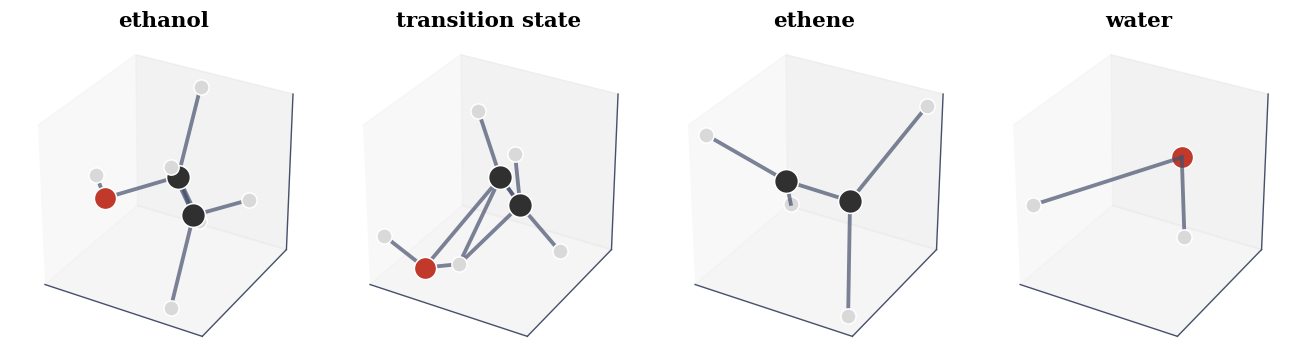

shortest C–O distance:  ethanol 1.43 Å  ->  transition state 1.90 Å (stretched)


In [3]:
# (solution hidden on the public site)


### Validation 1 — the transition state has a breaking C–O bond

In the dehydration the C–O bond breaks, so the C–O distance must be markedly longer
in the transition state than in the equilibrium ethanol (a normal C–O bond is
~1.4 Å).

In [4]:
validate.check(
    co_ts > co_ethanol + 0.3,
    "the transition state has a stretched (breaking) C–O bond",
    f"C–O: ethanol {co_ethanol:.2f} Å → TS {co_ts:.2f} Å",
)

✓  the transition state has a stretched (breaking) C–O bond   [C–O: ethanol 1.43 Å → TS 1.90 Å]


True

## Exercise 2 — The reaction-energy profile

Now the energies. For each method the course computed the total energy of every
species; the reaction profile is the energy relative to ethanol at three points along
the path: reactant (zero by definition), transition state (the barrier), and products
(ethene + water). We build it from the committed totals for all six method
combinations (Assignment 5).

**Part a)** Assemble the profiles in kcal/mol. **Part b)** Plot them and confirm every
transition state lies above its reactant.

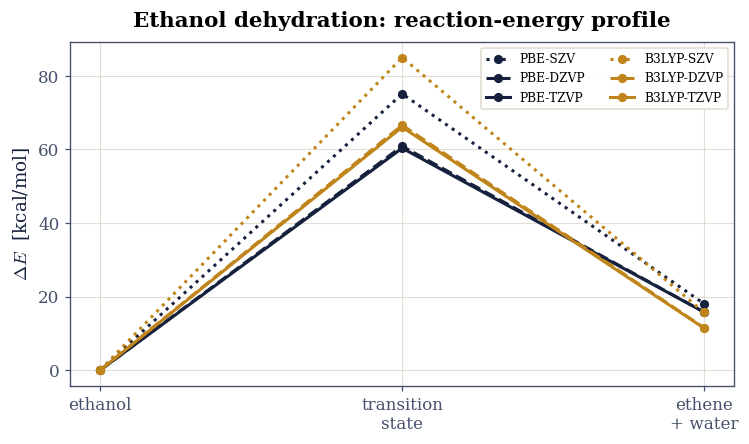

In [5]:
# (solution hidden on the public site)


### Validation 2 — every transition state is a barrier

A transition state is by definition a maximum along the path, so the barrier must be
positive for every method, and the reaction must be endothermic (products above
reactant) as ethanol dehydration is known to be.

In [6]:
validate.check(
    bool(np.all(barrier > 0)) and bool(np.all(reaction > 0)),
    "every method gives a positive barrier and an endothermic reaction",
    f"barriers {barrier.min():.0f}–{barrier.max():.0f}, reaction energies {reaction.min():.0f}–{reaction.max():.0f} kcal/mol",
)

✓  every method gives a positive barrier and an endothermic reaction   [barriers 60–85, reaction energies 11–18 kcal/mol]


True

## Exercise 3 — Convergence with functional and basis set

The whole point of the exercise: how much do the method choices matter? Plotting the
barrier against basis-set size for each functional shows the minimal **SZV** basis is
far from converged, while **DZVP** and **TZVP** agree closely, so the basis is
converged by triple-zeta. The two functionals still differ by a few kcal/mol at
convergence, with the hybrid **B3LYP-TZVP** the most reliable estimate, landing near
the experimental barrier of roughly 65–70 kcal/mol.

**Part a)** Tabulate barrier and reaction energy by method. **Part b)** Confirm the
basis is converged at TZVP and the B3LYP-TZVP barrier is in the experimental range.

method         barrier  reaction  (kcal/mol)
PBE-SZV           75.1      18.0
PBE-DZVP          60.9      15.8
PBE-TZVP          60.4      15.7
B3LYP-SZV         85.0      15.7
B3LYP-DZVP        66.6      11.5
B3LYP-TZVP        66.1      11.4


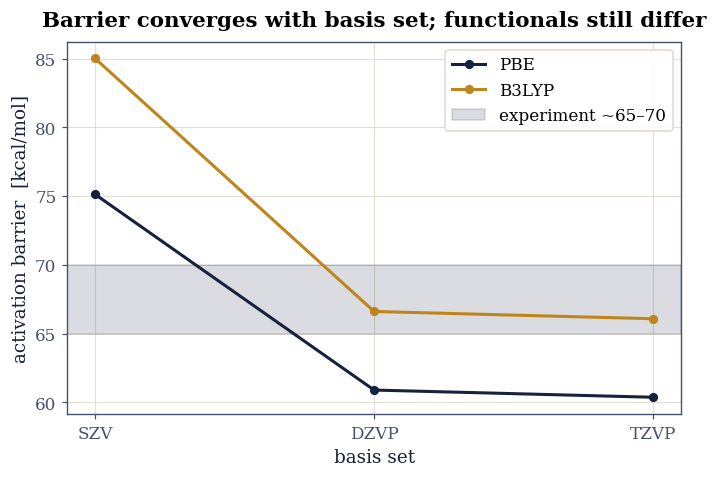

In [7]:
# (solution hidden on the public site)


### Validation 3 — converged at TZVP, and B3LYP lands on experiment

The barrier must be converged by triple-zeta (DZVP and TZVP within a couple of
kcal/mol), and the best method, B3LYP-TZVP, must fall in the measured range.

In [8]:
validate.check(
    basis_converged < 2.0,
    "the barrier is basis-set converged by TZVP (DZVP ≈ TZVP)",
    f"|B3LYP DZVP − TZVP| = {basis_converged:.2f} kcal/mol",
)
validate.check(
    60 < b3lyp_barrier[2] < 72,
    "the converged B3LYP-TZVP barrier matches the experimental range",
    f"B3LYP-TZVP barrier = {b3lyp_barrier[2]:.1f} kcal/mol (experiment ~65–70)",
)

✓  the barrier is basis-set converged by TZVP (DZVP ≈ TZVP)   [|B3LYP DZVP − TZVP| = 0.53 kcal/mol]
✓  the converged B3LYP-TZVP barrier matches the experimental range   [B3LYP-TZVP barrier = 66.1 kcal/mol (experiment ~65–70)]


True

## Exercise 4 — From barrier to reaction rate

The barrier matters because it sets the rate, exponentially. Through transition-state
theory {eq}`eq-eyring` the rate constant scales as $e^{-\Delta E^{\ddagger}/k_BT}$, so
the spread of barriers between methods becomes a spread of many orders of magnitude in
the predicted rate. We show this directly: the relative rate at a typical reaction
temperature, computed from each method's barrier, ranges over more than ten decades
(Assignment 6).

**Part a)** Compute the relative Boltzmann rate factor at $T=600\,$K for each method.
**Part b)** Confirm the method choice changes the predicted rate by many orders of
magnitude.

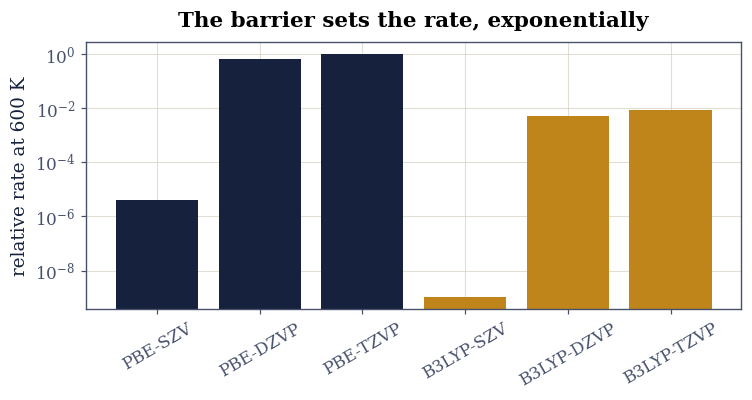

predicted rate varies by a factor of 9.5e+08 across the six methods at 600 K


In [9]:
# (solution hidden on the public site)


### Validation 4 — the rate spans many orders of magnitude

Because $k\propto e^{-\Delta E^{\ddagger}/k_BT}$, the ~25 kcal/mol spread of barriers
must translate into many orders of magnitude in rate, the practical reason method
convergence matters.

In [10]:
validate.check(
    rate_spread > 1e3,
    "the method choice changes the predicted rate by orders of magnitude",
    f"fastest/slowest rate = {rate_spread:.1e} at {T:.0f} K",
)

✓  the method choice changes the predicted rate by orders of magnitude   [fastest/slowest rate = 9.5e+08 at 600 K]


True

## Going further

- **The full path.** A nudged-elastic-band calculation (next notebook) finds the
  transition state and the minimum-energy path, rather than assuming a single TS
  geometry.
- **Free energy, not just energy.** Adding vibrational entropy gives the activation
  *free* energy $\Delta G^{\ddagger}$ and the absolute Eyring prefactor
  $k_BT/h$, hence an actual rate in s⁻¹.
- **Dispersion and exact exchange.** B3LYP's admixture of exact exchange improves
  barriers; adding a dispersion correction (D3) matters more for larger molecules.
- **Catalysis.** The gas-phase barrier here is large; an acid catalyst opens a lower
  path, the reason the reaction is run over a catalyst in practice.

### References

```{bibliography}
:filter: docname in docnames
```

In [11]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>